=== 🎵 ADVANCED BINARY AUDIO CLASSIFICATION (DEEP) ===
🎵 COLLECTING BINARY DATASET (KASAR vs TIDAK_KASAR)
Root   : D:\web\cnn_clasification\archive\Data\genres_original
Classes: ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblok', 'audiojancuk', 'audiotai', 'audiotolol']

📂 Processing class: audioanjing (D:\web\cnn_clasification\archive\Data\genres_original\audioanjing)
   Ditemukan 25 file audio (semua ekstensi)
   [1/25] anjing1.wav
✅ anjing1.wav: 246 features
   [2/25] anjing13.wav
✅ anjing13.wav: 246 features
   [3/25] anjing14.wav
✅ anjing14.wav: 246 features
   [4/25] anjing15.wav
✅ anjing15.wav: 246 features
   [5/25] anjing19.wav
✅ anjing19.wav: 246 features
   [6/25] anjing20.wav
✅ anjing20.wav: 246 features
   [7/25] anjing21.wav
✅ anjing21.wav: 246 features
   [8/25] anjing23.wav
✅ anjing23.wav: 246 features
   [9/25] anjing24.wav
✅ anjing24.wav: 246 features
   [10/25] anjing25.wav
✅ anjing25.wav: 246 features
   [11/25] anjing29.wav
✅ anjing29.wav: 2

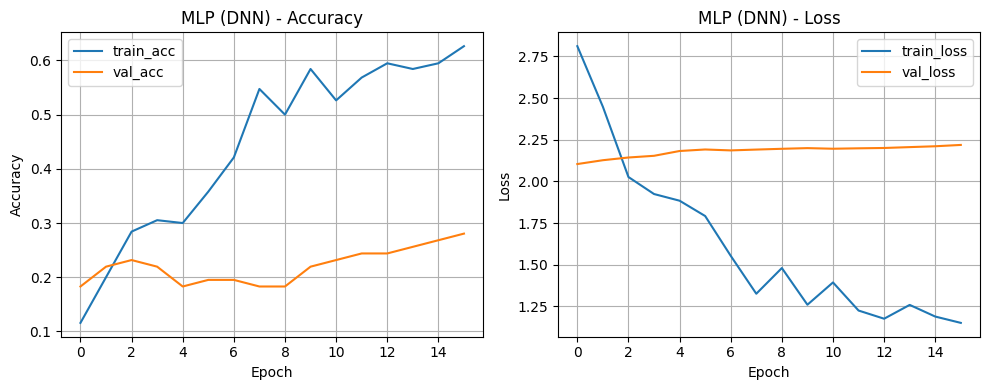


🔧 Training CNN1D...
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.3158 - loss: 1.9690 - val_accuracy: 0.3293 - val_loss: 2.0398 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3368 - loss: 1.8235 - val_accuracy: 0.3049 - val_loss: 1.9684 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3947 - loss: 1.6769 - val_accuracy: 0.3171 - val_loss: 1.9470 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4421 - loss: 1.5747 - val_accuracy: 0.3171 - val_loss: 1.9715 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4474 - loss: 1.4934 - val_accuracy: 0.3171 - val_loss: 2.0721 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5000 - loss: 1.3701 - val_accuracy: 0.3171 - val_loss: 2.2471 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5

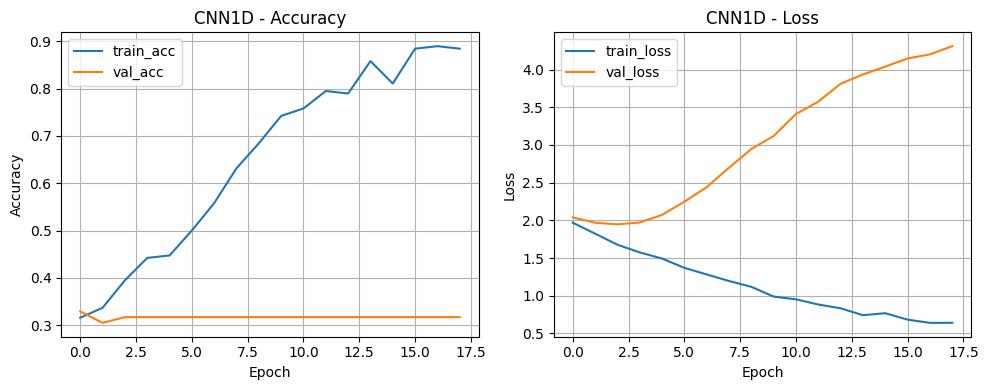


🎯 BEST MODEL: CNN1D
📊 BEST ACCURACY: 0.3171

📈 DETAILED CLASSIFICATION REPORT:
               precision    recall  f1-score   support

  audioanjing     0.0000    0.0000    0.0000         8
    audiobabi     0.0000    0.0000    0.0000         7
audiobajingan     0.0000    0.0000    0.0000         7
 audiobangsat     0.0000    0.0000    0.0000         6
  audiogoblok     0.0000    0.0000    0.0000        14
  audiojancuk     0.3171    1.0000    0.4815        26
     audiotai     0.0000    0.0000    0.0000         4
   audiotolol     0.0000    0.0000    0.0000        10

     accuracy                         0.3171        82
    macro avg     0.0396    0.1250    0.0602        82
 weighted avg     0.1005    0.3171    0.1527        82



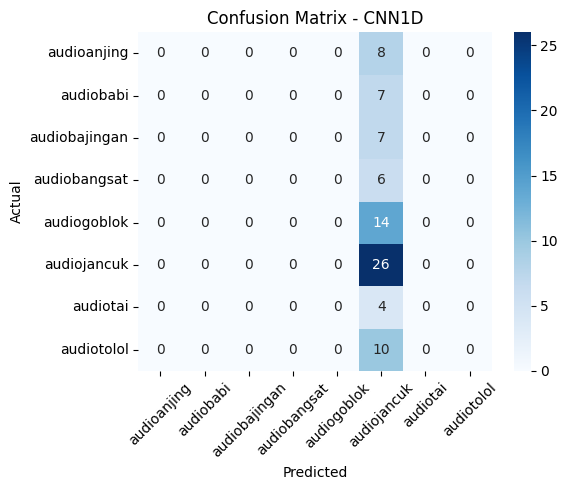


💾 Saved best model as 'best_audio_binary_model.keras'
💾 Saved scaler & class_names as 'audio_binary_meta.pkl'

🎉 FINAL ANALYSIS
🔶 PERLU IMPROVEMENT: Accuracy: 0.3171

📊 Details:
   Best Model : CNN1D
   Total Data : 272
   Fitur      : 246
   Classes    : 8 -> ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblok', 'audiojancuk', 'audiotai', 'audiotolol']


In [6]:
# ============================================================
#  ADVANCED BINARY AUDIO CLASSIFICATION (KASAR vs TIDAK_KASAR)
#  - Ekstraksi fitur MFCC + delta + delta2 + fitur dasar
#  - Model: MLP (DNN) & CNN1D
#  - Output: pilih model terbaik, simpan ke disk
# ============================================================

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ------------------------------------------------------------
# KONFIGURASI
# ------------------------------------------------------------
# GANTI path ini ke folder binary kamu:
#   binary_kasar\
#       ├─ kasar\
#       └─ tidak_kasar\
DATA_DIR = r"D:\web\cnn_clasification\archive\Data\genres_original"

SR = 22050
DURATION = 2.0        # detik
SEED = 42
BATCH_SIZE = 16
EPOCHS = 100

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# EKSTRAKSI FITUR YANG STABIL
# ------------------------------------------------------------
def extract_advanced_features(audio_path, sr=22050, duration=2.0):
    """
    Ekstraksi fitur yang stabil & aman:
    - MFCC (40)
    - Delta MFCC
    - Delta-delta MFCC
    - ZCR, RMS, Spectral Centroid (statistik)
    Output SELALU vektor 1D float32 (tidak ada array bersarang).
    """
    try:
        # 1) Load audio mono
        y, sr = librosa.load(audio_path, sr=sr, mono=True)

        # 2) Trim silence (biar fokus bagian yang ada suaranya)
        y_trimmed, _ = librosa.effects.trim(y, top_db=25)
        if len(y_trimmed) > 0:
            y = y_trimmed

        # 3) Fix length ke 'duration' detik (cut/pad)
        target_length = int(sr * duration)
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        # 4) MFCC dasar
        n_mfcc = 40
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # 5) Delta & delta-delta
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

        # Helper: ambil mean & std per-koefisien lalu concat
        def stats(feat):
            feat = np.asarray(feat)
            return np.concatenate(
                [np.mean(feat, axis=1), np.std(feat, axis=1)],
                axis=0
            )  # -> 80 dim untuk 40 MFCC

        mfcc_stats       = stats(mfcc)        # 80 dim
        mfcc_delta_stats = stats(mfcc_delta)  # 80 dim
        mfcc_dd_stats    = stats(mfcc_delta2) # 80 dim

        # 6) Beberapa fitur tambahan (scalar)
        zcr = librosa.feature.zero_crossing_rate(y)
        rms = librosa.feature.rms(y=y)
        spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

        extra = np.array([
            np.mean(zcr), np.std(zcr),
            np.mean(rms), np.std(rms),
            np.mean(spec_centroid), np.std(spec_centroid),
        ], dtype=np.float32)

        # 7) Gabungkan semua fitur jadi 1 vektor
        features = np.concatenate(
            [mfcc_stats, mfcc_delta_stats, mfcc_dd_stats, extra],
            axis=0
        )

        # Pastikan tidak ada NaN
        features = np.nan_to_num(features).astype(np.float32)

        print(f"✅ {Path(audio_path).name}: {features.shape[0]} features")
        return features

    except Exception as e:
        print(f"❌ {Path(audio_path).name}: {e}")
        return None


# ------------------------------------------------------------
# PENGUMPULAN DATASET BINARY (KASAR vs TIDAK_KASAR)
# ------------------------------------------------------------
def collect_dataset_binary(data_dir, samples_per_class=None):
    """
    Baca folder data_dir yang berisi subfolder per kelas.
    Contoh:
      data_dir/
        ├─ kasar/
        └─ tidak_kasar/

    samples_per_class: kalau None, ambil semua file.
    """
    data_root = Path(data_dir)
    if not data_root.exists():
        raise RuntimeError(f"DATA_DIR tidak ditemukan: {data_root}")

    class_dirs = [d for d in data_root.iterdir() if d.is_dir()]
    class_dirs.sort()
    class_names = [d.name for d in class_dirs]

    if len(class_dirs) < 2:
        raise RuntimeError(
            f"Minimal butuh 2 kelas. Ditemukan: {class_names}"
        )

    print("🎵 COLLECTING BINARY DATASET (KASAR vs TIDAK_KASAR)")
    print(f"Root   : {data_root}")
    print(f"Classes: {class_names}")
    print("=" * 60)

    X = []
    y = []
    files_used = []

    valid_ext = ['.wav', '.mp3', '.flac', '.ogg', '.m4a', '.aac']

    for class_idx, class_dir in enumerate(class_dirs):
        print(f"\n📂 Processing class: {class_names[class_idx]} ({class_dir})")

        audio_files = []
        for ext in valid_ext:
            audio_files.extend(list(class_dir.glob(f"*{ext}")))

        audio_files = sorted(audio_files)
        print(f"   Ditemukan {len(audio_files)} file audio (semua ekstensi)")

        if len(audio_files) == 0:
            print("   ⚠️  Tidak ada file audio, skip kelas ini.")
            continue

        # Batasi sampel per kelas kalau di-set
        if samples_per_class is not None and len(audio_files) > samples_per_class:
            audio_files = audio_files[:samples_per_class]

        processed = 0
        for i, audio_file in enumerate(audio_files):
            print(f"   [{i+1}/{len(audio_files)}] {audio_file.name}")
            feats = extract_advanced_features(str(audio_file), sr=SR, duration=DURATION)
            if feats is None:
                continue
            X.append(feats)
            y.append(class_idx)
            files_used.append(str(audio_file))
            processed += 1

        print(f"   🎯 Berhasil ekstrak: {processed}/{len(audio_files)} file")

    if len(X) == 0:
        print("\n❌ Tidak ada fitur yang berhasil diekstrak.")
        print("   Cek:")
        print("   1) DATA_DIR sudah benar?")
        print("   2) Di dalamnya ada subfolder per kelas?")
        print(f"   3) Di dalam setiap subfolder ada file audio dengan ekstensi: {valid_ext}")
        raise RuntimeError("❌ No features extracted. Cek path DATA_DIR atau format audio.")

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    print("\n📊 ADVANCED DATASET CREATED!")
    print(f"   Total samples    : {X.shape[0]}")
    print(f"   Features / sample: {X.shape[1]}")
    print(f"   Classes          : {len(class_names)} -> {class_names}")

    return X, y, class_names, files_used


# ------------------------------------------------------------
# MODEL: MLP (DNN) & CNN1D
# ------------------------------------------------------------
def build_mlp(input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,), name="mlp_input")
    x = layers.Dense(256, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="MLP_Classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_cnn1d(input_length, num_classes):
    """
    CNN1D di atas vektor fitur 1D (246 dim).
    Kita treat sebagai "sinyal 1D" dengan 1 channel.
    """
    inputs = keras.Input(shape=(input_length, 1), name="cnn1d_input")

    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="CNN1D_Classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# ------------------------------------------------------------
# UTIL: PLOT HISTORY & CONFUSION MATRIX
# ------------------------------------------------------------
def plot_history(history, title="Training History"):
    plt.figure(figsize=(10, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("accuracy", []), label="train_acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("loss", []), label="train_loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# TRAINING WRAPPER
# ------------------------------------------------------------
def train_deep_models(X, y, class_names):
    print("\n🤖 TRAINING DEEP LEARNING MODELS")
    print("=" * 50)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=y
    )

    print("📈 Data Split:")
    print(f"   Training: {X_train.shape[0]} samples")
    print(f"   Testing : {X_test.shape[0]} samples")
    print(f"   Features: {X_train.shape[1]}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    input_dim = X_train_scaled.shape[1]
    num_classes = len(class_names)

    # Callback
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )

    results = {}

    # --------------------------------------------------------
    # 1) MLP / DNN
    # --------------------------------------------------------
    print("\n🔧 Training MLP (DNN)...")
    mlp = build_mlp(input_dim, num_classes)
    mlp_history = mlp.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    y_pred_mlp = np.argmax(mlp.predict(X_test_scaled), axis=1)
    acc_mlp = accuracy_score(y_test, y_pred_mlp)
    print(f"   ✅ MLP Accuracy: {acc_mlp:.4f}")

    results["MLP"] = {
        "model": mlp,
        "history": mlp_history,
        "accuracy": acc_mlp,
        "y_pred": y_pred_mlp,
    }

    plot_history(mlp_history, title="MLP (DNN)")

    # --------------------------------------------------------
    # 2) CNN1D
    # --------------------------------------------------------
    print("\n🔧 Training CNN1D...")
    # reshape ke (samples, timesteps, channels)
    X_train_cnn = X_train_scaled[..., np.newaxis]
    X_test_cnn = X_test_scaled[..., np.newaxis]

    cnn1d = build_cnn1d(input_dim, num_classes)
    cnn_history = cnn1d.fit(
        X_train_cnn, y_train,
        validation_data=(X_test_cnn, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    y_pred_cnn = np.argmax(cnn1d.predict(X_test_cnn), axis=1)
    acc_cnn = accuracy_score(y_test, y_pred_cnn)
    print(f"   ✅ CNN1D Accuracy: {acc_cnn:.4f}")

    results["CNN1D"] = {
        "model": cnn1d,
        "history": cnn_history,
        "accuracy": acc_cnn,
        "y_pred": y_pred_cnn,
    }

    plot_history(cnn_history, title="CNN1D")

    # --------------------------------------------------------
    # PILIH MODEL TERBAIK
    # --------------------------------------------------------
    best_name = max(results.keys(), key=lambda k: results[k]["accuracy"])
    best_result = results[best_name]
    best_model = best_result["model"]
    best_acc = best_result["accuracy"]
    best_pred = best_result["y_pred"]

    print("\n🎯 BEST MODEL:", best_name)
    print(f"📊 BEST ACCURACY: {best_acc:.4f}")

    # Classification report
    print("\n📈 DETAILED CLASSIFICATION REPORT:")
    print(classification_report(y_test, best_pred, target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_test, best_pred)
    plot_confusion(cm, class_names, title=f"Confusion Matrix - {best_name}")

    # --------------------------------------------------------
    # SIMPAN MODEL & METADATA
    # --------------------------------------------------------
    best_model_path = "best_audio_binary_model.keras"
    meta_path = "audio_binary_meta.pkl"

    best_model.save(best_model_path)
    meta = {
        "scaler": scaler,
        "class_names": class_names,
        "input_dim": input_dim,
        "accuracy": best_acc,
        "model_name": best_name,
    }
    joblib.dump(meta, meta_path)

    print(f"\n💾 Saved best model as '{best_model_path}'")
    print(f"💾 Saved scaler & class_names as '{meta_path}'")

    return best_acc, best_name, results


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------
def main():
    print("=== 🎵 ADVANCED BINARY AUDIO CLASSIFICATION (DEEP) ===")
    print("=" * 60)

    try:
        # Step 1: Collect dataset
        X, y, class_names, files_used = collect_dataset_binary(
            DATA_DIR,
            samples_per_class=None  # set angka kalau mau batasi per kelas
        )

        # Step 2: Train deep models
        best_acc, best_name, results = train_deep_models(X, y, class_names)

        print("\n" + "=" * 60)
        print("🎉 FINAL ANALYSIS")
        print("=" * 60)

        if best_acc > 0.9:
            print(f"✅ LUAR BIASA! Accuracy: {best_acc:.4f}")
        elif best_acc > 0.8:
            print(f"✅ SANGAT BAGUS! Accuracy: {best_acc:.4f}")
        elif best_acc > 0.7:
            print(f"👍 CUKUP BAGUS: Accuracy: {best_acc:.4f}")
        elif best_acc > 0.5:
            print(f"⚠️  SEDANG: Accuracy: {best_acc:.4f}")
        else:
            print(f"🔶 PERLU IMPROVEMENT: Accuracy: {best_acc:.4f}")

        print(f"\n📊 Details:")
        print(f"   Best Model : {best_name}")
        print(f"   Total Data : {X.shape[0]}")
        print(f"   Fitur      : {X.shape[1]}")
        print(f"   Classes    : {len(class_names)} -> {class_names}")

    except Exception as e:
        print("\n❌ ERROR:", e)
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()
